# DSC 291 HW4 — XGBoost Taxi Type Classification

This notebook implements both:
- **Part A**: Classification from raw trip-level data.
- **Part B**: Classification from pivoted hourly profiles reduced by PCA.

Everything runs top-to-bottom as a single combined HW4 notebook.

## Dependencies

A `requirements.txt` for HW4 is included in the `HW4/` folder. The recommended setup is a dedicated virtual environment:

```bash
python -m venv .venv
source .venv/bin/activate          # Windows: .venv\Scripts\activate
pip install -r HW4/requirements.txt
```

Packages required: `numpy`, `pandas`, `dask[dataframe]`, `pyarrow`, `s3fs`, `xgboost`, `scikit-learn`, `matplotlib`, `python-dotenv`.

In [1]:
# Imports (shared by Part A and Part B)

import os
import re
from pathlib import Path

import dask.dataframe as dd
import fsspec
import numpy as np
import pandas as pd

from dotenv import load_dotenv

from sklearn.decomposition import PCA
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

print("Imports loaded.")

Imports loaded.


In [2]:
# Reproducibility: set global random seed

# Prefer to respect an existing RANDOM_SEED defined in the shared config cell.
# If this cell is run first, fall back to a default and also set RANDOM_SEED.
try:
    _seed = RANDOM_SEED
except NameError:
    _seed = 42
    RANDOM_SEED = _seed

np.random.seed(_seed)

In [3]:
# Shared configuration for HW4 Parts A and B

# Raw trip parquet root (directory or single file)
RAW_PARQUET_PATH = "s3://dsc291-ucsd/taxi"

# Pivoted parquet path (date × taxi_type × pickup_place × hour_0…hour_23)
PIVOT_PARQUET_PATH = "s3://291-s3-bucket/wide.parquet"

# Maximum rows per class for Part A (set to None to use all rows)
MAX_ROWS_PER_CLASS = 50_000

# Random seed and train fraction (used in both parts)
RANDOM_SEED = 42
TRAIN_FRAC = 0.80

# Number of PCA components for Part B
N_PCA_COMPONENTS = 5

# Bootstrap iterations (Part A extra credit vs Part B extra credit)
N_BOOTSTRAP_A = 30
N_BOOTSTRAP_B = 200

print("RAW_PARQUET_PATH", RAW_PARQUET_PATH)
print("PIVOT_PARQUET_PATH", PIVOT_PARQUET_PATH)
print("MAX_ROWS_PER_CLASS", MAX_ROWS_PER_CLASS)
print("RANDOM_SEED", RANDOM_SEED)
print("TRAIN_FRAC", TRAIN_FRAC)
print("N_PCA_COMPONENTS", N_PCA_COMPONENTS)
print("N_BOOTSTRAP_A", N_BOOTSTRAP_A)
print("N_BOOTSTRAP_B", N_BOOTSTRAP_B)

RAW_PARQUET_PATH s3://dsc291-ucsd/taxi
PIVOT_PARQUET_PATH s3://291-s3-bucket/wide.parquet
MAX_ROWS_PER_CLASS 50000
RANDOM_SEED 42
TRAIN_FRAC 0.8
N_PCA_COMPONENTS 5
N_BOOTSTRAP_A 30
N_BOOTSTRAP_B 200


In [4]:
# Load environment variables from a .env file.
# In Jupyter/nbconvert the working directory can vary, so we search common locations.

candidates = [
    Path.cwd() / ".env",
    Path.cwd() / "HW4" / ".env",
    Path.cwd() / "dsc-291-git" / "dsc291-2026" / "HW4" / ".env",
    Path.cwd().parent / ".env",
]

dotenv_path = next((p for p in candidates if p.exists()), None)
if dotenv_path is not None:
    # Override any stale AWS_* variables already set in the environment
    load_dotenv(dotenv_path=dotenv_path, override=True)
    print("AWS credentials loaded from .env (override=True)")
else:
    print("No .env found (ok if you exported AWS_* env vars another way).")

# Optional sanity check (don't print the values, just that they exist)
for name in ["AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY", "AWS_SESSION_TOKEN"]:
    v = os.getenv(name)
    print(name, "is set?", bool(v), "(has_spaces?", (" " in v) if v else False, ")")

if os.getenv("AWS_SESSION_TOKEN") and " " in os.getenv("AWS_SESSION_TOKEN"):
    raise ValueError(
        "AWS_SESSION_TOKEN contains spaces. Fix your .env so the token is one continuous string."
    )

AWS credentials loaded from .env (override=True)
AWS_ACCESS_KEY_ID is set? True (has_spaces? False )
AWS_SECRET_ACCESS_KEY is set? True (has_spaces? False )
AWS_SESSION_TOKEN is set? True (has_spaces? False )


### Note on FHV (For-Hire Vehicle) Data

The raw S3 bucket may contain FHV trip files (e.g. `fhv_tripdata_YYYY-MM.parquet`). FHV records use a different schema — they lack standardized `trip_distance`, `passenger_count`, and pickup/dropoff datetime columns that are present in yellow and green taxi files. Rather than attempting to normalize the incompatible schema, **this notebook restricts Part A to yellow and green taxi types only**. FHV files are ignored during discovery via the `YELLOW_RE` / `GREEN_RE` filename patterns below.

In [5]:
# Part A helpers: discovery + schema normalization for raw trip data

YELLOW_RE = re.compile(r"yellow[_-]tripdata", re.IGNORECASE)
GREEN_RE = re.compile(r"green[_-]tripdata", re.IGNORECASE)


def _get_fs_and_pattern(root: str):
    """Return (fs, glob_pattern, prefix) for a local or S3 root."""
    if root.startswith("s3://"):
        storage_options = {
            "key": os.getenv("AWS_ACCESS_KEY_ID"),
            "secret": os.getenv("AWS_SECRET_ACCESS_KEY"),
            "token": os.getenv("AWS_SESSION_TOKEN"),
        }
        storage_options = {k: v for k, v in storage_options.items() if v is not None}
        fs = fsspec.filesystem("s3", **storage_options)
        _, _, bare = root.partition("s3://")
        pattern = bare.rstrip("/") + "/**/*.parquet"
        prefix = "s3://"
    else:
        fs = fsspec.filesystem("file")
        pattern = os.path.join(root, "**", "*.parquet")
        prefix = ""
    return fs, pattern, prefix


def discover_trip_files(root: str):
    """Return (yellow_files, green_files) under a root directory or single parquet file.

    - If `root` is a single parquet file, classify it by filename.
    - Otherwise, glob recursively for *.parquet.
    """
    if root.rstrip("/").endswith(".parquet"):
        fname = os.path.basename(root)
        if YELLOW_RE.search(fname):
            return [root], []
        if GREEN_RE.search(fname):
            return [], [root]
        # Unknown type → treat as yellow by default
        return [root], []

    fs, pattern, prefix = _get_fs_and_pattern(root)
    candidates = fs.glob(pattern)
    yellow_files, green_files = [], []
    for p in candidates:
        fname = os.path.basename(p)
        full = prefix + p
        if YELLOW_RE.search(fname):
            yellow_files.append(full)
        elif GREEN_RE.search(fname):
            green_files.append(full)
    yellow_files.sort()
    green_files.sort()
    return yellow_files, green_files


def _extract_year_month(path: str):
    """Extract (year, month) from filename, e.g. yellow_tripdata_2009-01.parquet -> (2009, 1)."""
    fname = os.path.basename(path)
    m = re.search(r"(\d{4})-(\d{2})", fname)
    if m:
        return int(m.group(1)), int(m.group(2))
    return 0, 0


def _pick_matched_files(yellow_files, green_files):
    """Pick one yellow and one green file from the same (year, month) when possible.

    This avoids temporal confounds between classes.
    """
    yellow_ym = {_extract_year_month(p): p for p in yellow_files}
    green_ym = {_extract_year_month(p): p for p in green_files}
    common = set(yellow_ym.keys()) & set(green_ym.keys())
    common.discard((0, 0))
    if common:
        y, m = sorted(common)[0]
        return yellow_ym[(y, m)], green_ym[(y, m)]

    # Fallback: closest in year if no exact month match
    best_diff, best_y, best_g = float("inf"), None, None
    for yp in yellow_files:
        yy, ym = _extract_year_month(yp)
        for gp in green_files:
            gy, gm = _extract_year_month(gp)
            if abs(yy - gy) < best_diff:
                best_diff = abs(yy - gy)
                best_y, best_g = yp, gp
    return best_y, best_g


_CANONICAL_VARIANTS = {
    "pickup_datetime": [
        "tpep_pickup_datetime",
        "lpep_pickup_datetime",
        "trip_pickup_datetime",
        "pickup_datetime",
    ],
    "dropoff_datetime": [
        "tpep_dropoff_datetime",
        "lpep_dropoff_datetime",
        "trip_dropoff_datetime",
        "dropoff_datetime",
    ],
    "trip_distance": ["trip_distance", "trip_miles"],
    "passenger_count": ["passenger_count"],
}


def normalize_trip_schema(ddf: dd.DataFrame) -> dd.DataFrame:
    """Rename columns to a canonical schema for Part A.

    Required canonical columns:
    - pickup_datetime
    - dropoff_datetime
    - trip_distance
    - passenger_count
    """
    cols = list(ddf.columns)
    lower_to_orig = {c.lower(): c for c in cols}
    rename = {}
    for canonical, variants in _CANONICAL_VARIANTS.items():
        for v in variants:
            if v.lower() in lower_to_orig:
                rename[lower_to_orig[v.lower()]] = canonical
                break
    ddf2 = ddf.rename(columns=rename)
    required = {"pickup_datetime", "dropoff_datetime", "trip_distance", "passenger_count"}
    missing = required - set(ddf2.columns)
    if missing:
        raise KeyError(f"Missing required columns after normalization: {missing}")
    return ddf2

In [6]:
def _load_single_file_to_pandas(path: str, taxi_type: str, max_rows: int | None, random_state: int) -> pd.DataFrame:
    """Load one parquet file with Dask, normalize schema, derive features, and sample rows.

    Derives the required features for Part A:
    - trip_duration_min
    - hour
    - day_of_week
    """
    storage_options = None
    if path.startswith("s3://"):
        storage_options = {
            "key": os.getenv("AWS_ACCESS_KEY_ID"),
            "secret": os.getenv("AWS_SECRET_ACCESS_KEY"),
            "token": os.getenv("AWS_SESSION_TOKEN"),
        }
        storage_options = {k: v for k, v in storage_options.items() if v is not None}

    ddf = dd.read_parquet(path, engine="pyarrow", storage_options=storage_options)
    ddf = normalize_trip_schema(ddf)
    ddf = ddf[["pickup_datetime", "dropoff_datetime", "trip_distance", "passenger_count"]]
    ddf = ddf.assign(taxi_type=taxi_type)

    # Approximate downsampling in Dask for speed, then enforce an exact per-class cap in pandas
    # (deterministic via random_state) for reproducibility.
    if max_rows is not None:
        ddf = ddf.sample(frac=0.10, random_state=random_state)

    pdf = ddf.compute()

    # Ensure datetime dtype for feature derivation
    pdf["pickup_datetime"] = pd.to_datetime(pdf["pickup_datetime"], errors="coerce")
    pdf["dropoff_datetime"] = pd.to_datetime(pdf["dropoff_datetime"], errors="coerce")

    # Derived columns
    pdf["trip_duration_min"] = (
        pdf["dropoff_datetime"] - pdf["pickup_datetime"]
    ).dt.total_seconds() / 60.0
    pdf["hour"] = pdf["pickup_datetime"].dt.hour
    pdf["day_of_week"] = pdf["pickup_datetime"].dt.dayofweek

    # Drop missing/invalid values
    pdf = pdf.dropna(
        subset=[
            "pickup_datetime",
            "dropoff_datetime",
            "trip_distance",
            "passenger_count",
            "trip_duration_min",
            "hour",
            "day_of_week",
        ]
    )
    pdf = pdf[(pdf["trip_distance"] > 0) & (pdf["trip_duration_min"] > 0)]

    # Sample per class so notebook runs quickly
    if max_rows is not None and len(pdf) > max_rows:
        pdf = pdf.sample(n=max_rows, random_state=random_state)

    pdf = pdf.reset_index(drop=True)
    return pdf


def load_partA_trip_sample(
    root: str | None = None,
    max_rows_per_class: int | None = None,
    random_state: int = RANDOM_SEED,
) -> pd.DataFrame:
    """Load and return a cleaned, balanced sample for Part A.

    - Root may be a directory or a single parquet path.
    - Ensures one yellow and one green file from the same (year, month) when possible.
    - Returns a pandas DataFrame with all required features + `taxi_type`.
    """
    if root is None:
        root = RAW_PARQUET_PATH
    if max_rows_per_class is None:
        max_rows_per_class = MAX_ROWS_PER_CLASS

    yellow_files, green_files = discover_trip_files(root)
    if not yellow_files or not green_files:
        raise RuntimeError(
            f"Need both yellow and green files under {root}; yellow={len(yellow_files)}, green={len(green_files)}"
        )

    yellow_path, green_path = _pick_matched_files(yellow_files, green_files)
    ym_y = _extract_year_month(yellow_path)
    ym_g = _extract_year_month(green_path)
    print(f"[Part A] yellow: {yellow_path} ({ym_y[0]}-{ym_y[1]:02d})")
    print(f"[Part A] green:  {green_path} ({ym_g[0]}-{ym_g[1]:02d})")

    df_yellow = _load_single_file_to_pandas(
        yellow_path, "yellow", max_rows_per_class, random_state
    )
    df_green = _load_single_file_to_pandas(
        green_path, "green", max_rows_per_class, random_state + 1
    )

    df = pd.concat([df_yellow, df_green], ignore_index=True)
    print(f"[Part A] Yellow rows (post-clean): {len(df_yellow):,}")
    print(f"[Part A] Green  rows (post-clean): {len(df_green):,}")
    print(f"[Part A] Combined (post-clean): {len(df):,}")

    return df


# Load Part A data
print("\nLoading Part A trip sample...")
df_partA = load_partA_trip_sample()
cols_preview = [
    "trip_distance",
    "trip_duration_min",
    "hour",
    "day_of_week",
    "passenger_count",
    "taxi_type",
]
print("\nPart A preview:")
display(df_partA[cols_preview].head())


Loading Part A trip sample...


[Part A] yellow: s3://dsc291-ucsd/taxi/Dataset/2014/yellow_taxi/yellow_tripdata_2014-01.parquet (2014-01)
[Part A] green:  s3://dsc291-ucsd/taxi/Dataset/2014/green_taxi/green_tripdata_2014-01.parquet (2014-01)


[Part A] Yellow rows (post-clean): 50,000
[Part A] Green  rows (post-clean): 50,000
[Part A] Combined (post-clean): 100,000

Part A preview:


,trip_distance,trip_duration_min,hour,day_of_week,passenger_count,taxi_type
0,2.79,10.00,22,5,1,yellow
1,7.18,19.00,23,3,1,yellow
2,1.99,9.00,1,6,1,yellow
3,0.70,7.05,9,3,2,yellow
4,1.53,5.00,22,5,1,yellow


[Part A] Classes: ['green' 'yellow'] -> 0..1
[Part A] Train: 80,000, Test: 20,000


[Part A] Accuracy: 0.7773

[Part A] Classification Report:
              precision    recall  f1-score   support

       green       0.77      0.79      0.78     10000
      yellow       0.79      0.76      0.77     10000

    accuracy                           0.78     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.78      0.78      0.78     20000



/var/folders/3f/8cj7z5g103l7wv24bccyds5r0000gn/T/ipykernel_80709/2564225427.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


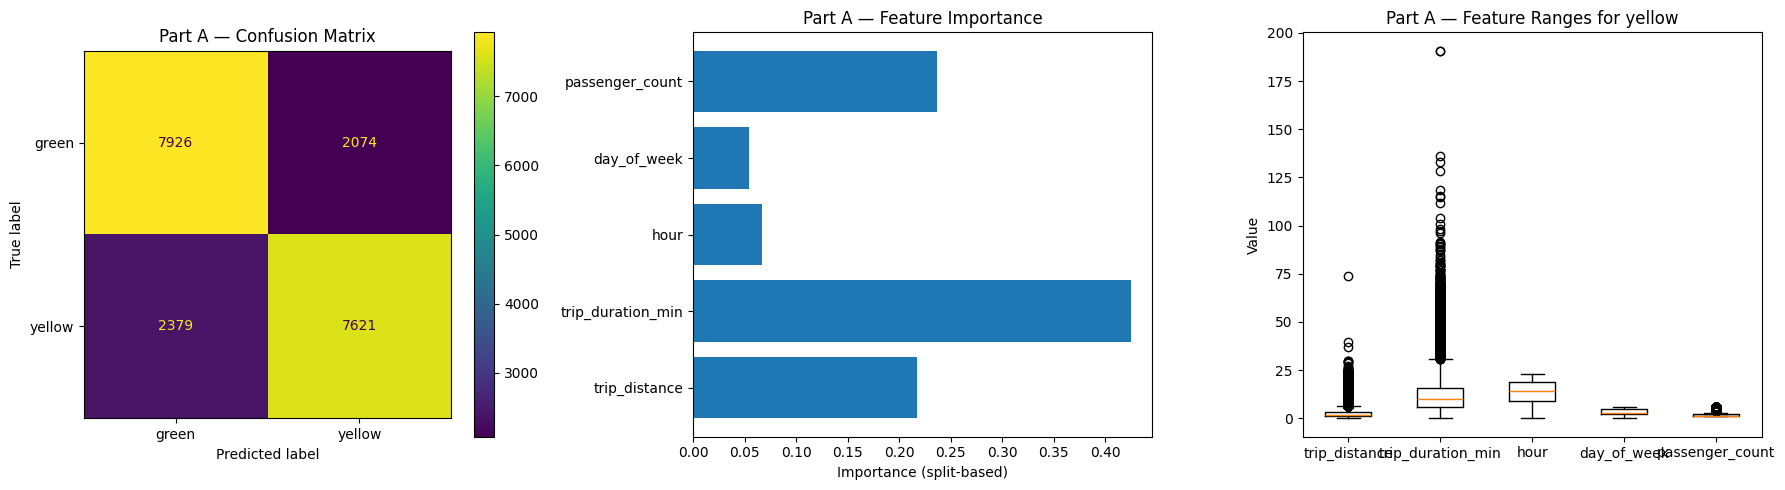

In [7]:
# Part A: Train, evaluate, and interpret XGBoost on raw trip features

# Features for Part A
FEATURE_COLS_A = [
    "trip_distance",
    "trip_duration_min",
    "hour",
    "day_of_week",
    "passenger_count",
]

X_A = df_partA[FEATURE_COLS_A].values
y_A_raw = df_partA["taxi_type"].values

# Encode labels
le_A = LabelEncoder()
y_A = le_A.fit_transform(y_A_raw)
classes_A = le_A.classes_
n_class_A = len(classes_A)
print(f"[Part A] Classes: {classes_A} -> 0..{n_class_A-1}")

# Stratified train/validation split
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A,
    y_A,
    train_size=TRAIN_FRAC,
    stratify=y_A,
    random_state=RANDOM_SEED,
)
print(f"[Part A] Train: {len(X_train_A):,}, Test: {len(X_test_A):,}")

# Fit XGBClassifier for Part A
xgb_A = XGBClassifier(
    objective="multi:softmax",
    num_class=n_class_A,
    random_state=RANDOM_SEED,
    n_jobs=1,
    eval_metric="mlogloss",
)

xgb_A.fit(X_train_A, y_train_A)

y_pred_A = xgb_A.predict(X_test_A)
acc_A = accuracy_score(y_test_A, y_pred_A)
print(f"[Part A] Accuracy: {acc_A:.4f}")
print("\n[Part A] Classification Report:")
print(classification_report(y_test_A, y_pred_A, target_names=classes_A))

# Interpretation: confusion matrix, feature importance, and feature distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_A,
    y_pred_A,
    display_labels=classes_A,
    ax=axes[0],
    colorbar=True,
)
axes[0].set_title("Part A — Confusion Matrix")

# Feature importance from XGBoost
importance_A = xgb_A.feature_importances_
axes[1].barh(FEATURE_COLS_A, importance_A)
axes[1].set_xlabel("Importance (split-based)")
axes[1].set_title("Part A — Feature Importance")

# Feature distributions for one class (e.g. yellow)
focus_class = "yellow" if "yellow" in classes_A else classes_A[0]
mask_focus = df_partA["taxi_type"] == focus_class
axes[2].boxplot(
    [df_partA.loc[mask_focus, col].values for col in FEATURE_COLS_A],
    labels=FEATURE_COLS_A,
    vert=True,
)
axes[2].set_title(f"Part A — Feature Ranges for {focus_class}")
axes[2].set_ylabel("Value")

plt.tight_layout()
plt.show()

### Part A — Extra Credit: Hyperparameter study + bootstrap stability

Here we (1) sweep a small grid of XGBoost hyperparameters for Part A and (2) run a bootstrap analysis to quantify stability of accuracy and F1 on the Part A test set.

In [8]:
# Part A — Extra Credit: hyperparameter sweep + bootstrap stability

# 1) Small hyperparameter sweep on Part A

param_grid = [
    {"max_depth": 4, "learning_rate": 0.05},
    {"max_depth": 4, "learning_rate": 0.10},
    {"max_depth": 6, "learning_rate": 0.05},
    {"max_depth": 6, "learning_rate": 0.10},
    {"max_depth": 8, "learning_rate": 0.10},
]

print("=== Part A hyperparameter sweep (accuracy + macro-F1) ===")
results_A = []

for params in param_grid:
    xgb_sweep = XGBClassifier(
        objective="multi:softmax",
        num_class=n_class_A,
        random_state=RANDOM_SEED,
        n_jobs=1,
        eval_metric="mlogloss",
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
    )
    xgb_sweep.fit(X_train_A, y_train_A)

    y_pred_sweep = xgb_sweep.predict(X_test_A)
    acc = accuracy_score(y_test_A, y_pred_sweep)
    macro_f1 = f1_score(y_test_A, y_pred_sweep, average="macro")

    results_A.append((params["max_depth"], params["learning_rate"], acc, macro_f1))
    print(
        f"max_depth={params['max_depth']:<2d}, "
        f"eta={params['learning_rate']:<.2f}  "
        f"acc={acc:.4f}, macro-F1={macro_f1:.4f}"
    )

# 2) Bootstrap stability on the *chosen* Part A model (xgb_A)

print("\n=== Part A bootstrap stability (test set resampling) ===")
n_boot = 200
rng = np.random.RandomState(RANDOM_SEED)

acc_boot = []
f1_boot = []

for b in range(n_boot):
    idx = rng.randint(0, len(y_test_A), size=len(y_test_A))
    y_true_b = y_test_A[idx]
    y_pred_b = xgb_A.predict(X_test_A[idx])

    acc_boot.append(accuracy_score(y_true_b, y_pred_b))
    f1_boot.append(f1_score(y_true_b, y_pred_b, average="macro"))

acc_boot = np.array(acc_boot)
f1_boot = np.array(f1_boot)

def ci_95(x):
    lo = np.percentile(x, 2.5)
    hi = np.percentile(x, 97.5)
    return lo, hi

acc_lo, acc_hi = ci_95(acc_boot)
f1_lo, f1_hi = ci_95(f1_boot)

print(
    f"Accuracy: mean={acc_boot.mean():.4f}, "
    f"sd={acc_boot.std():.4f}, "
    f"95% CI= [{acc_lo:.4f}, {acc_hi:.4f}]"
)
print(
    f"Macro-F1: mean={f1_boot.mean():.4f}, "
    f"sd={f1_boot.std():.4f}, "
    f"95% CI= [{f1_lo:.4f}, {f1_hi:.4f}]"
)

=== Part A hyperparameter sweep (accuracy + macro-F1) ===


max_depth=4 , eta=0.05  acc=0.7088, macro-F1=0.7072


max_depth=4 , eta=0.10  acc=0.7309, macro-F1=0.7288


max_depth=6 , eta=0.05  acc=0.7280, macro-F1=0.7263


max_depth=6 , eta=0.10  acc=0.7565, macro-F1=0.7553


max_depth=8 , eta=0.10  acc=0.7655, macro-F1=0.7648

=== Part A bootstrap stability (test set resampling) ===


Accuracy: mean=0.7774, sd=0.0031, 95% CI= [0.7714, 0.7836]
Macro-F1: mean=0.7774, sd=0.0031, 95% CI= [0.7714, 0.7836]


[Part A] Bootstrap iteration 10/30 done


[Part A] Bootstrap iteration 20/30 done


[Part A] Bootstrap iteration 30/30 done

[Part A] Bootstrap Accuracy (30 iterations):
  Mean:     0.7531
  Std:      0.0034
  Variance: 0.000012
  95% CI:   [0.7476, 0.7596]

[Part A] Prediction Confidence (ensemble of 30 models):
  Mean max-probability: 0.6854
  Median:               0.6761


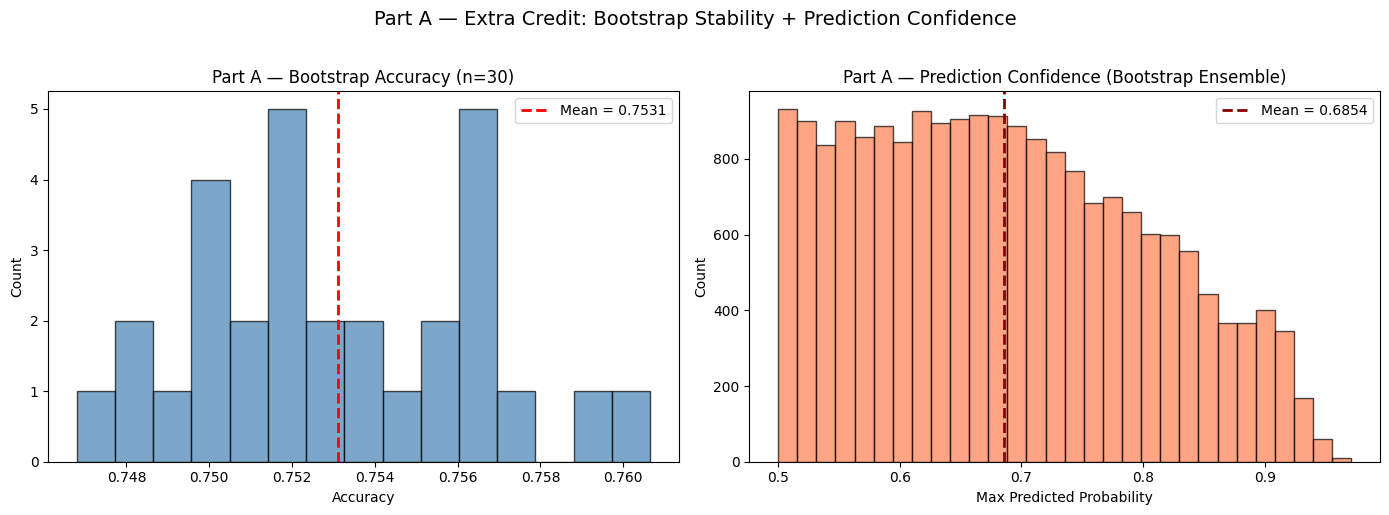

In [9]:
# Part A — Extra Credit: bootstrap stability + prediction confidence (ensemble)

bootstrap_accuracies_A = []
all_proba_A = []

for i in range(N_BOOTSTRAP_A):
    # Bootstrap resample on the Part A training set
    X_boot_A, y_boot_A = resample(
        X_train_A, y_train_A, random_state=RANDOM_SEED + i
    )

    boot_model_A = XGBClassifier(
        objective="multi:softprob",
        num_class=n_class_A,
        random_state=RANDOM_SEED,
        n_jobs=1,
        eval_metric="mlogloss",
        max_depth=6,
        learning_rate=0.10,
    )
    boot_model_A.fit(X_boot_A, y_boot_A)

    proba_A = boot_model_A.predict_proba(X_test_A)
    preds_A = proba_A.argmax(axis=1)
    acc_A_boot = accuracy_score(y_test_A, preds_A)

    bootstrap_accuracies_A.append(acc_A_boot)
    all_proba_A.append(proba_A)

    if (i + 1) % 10 == 0:
        print(f"[Part A] Bootstrap iteration {i + 1}/{N_BOOTSTRAP_A} done")

bootstrap_accuracies_A = np.array(bootstrap_accuracies_A)
all_proba_A = np.array(all_proba_A)

# Ensemble prediction confidence: average probabilities across bootstrap models
mean_proba_A = all_proba_A.mean(axis=0)
pred_confidence_A = mean_proba_A.max(axis=1)

# Summary stats
acc_mean_A = bootstrap_accuracies_A.mean()
acc_std_A = bootstrap_accuracies_A.std()
acc_var_A = bootstrap_accuracies_A.var()
acc_ci_A = np.percentile(bootstrap_accuracies_A, [2.5, 97.5])

print(f"\n[Part A] Bootstrap Accuracy ({N_BOOTSTRAP_A} iterations):")
print(f"  Mean:     {acc_mean_A:.4f}")
print(f"  Std:      {acc_std_A:.4f}")
print(f"  Variance: {acc_var_A:.6f}")
print(f"  95% CI:   [{acc_ci_A[0]:.4f}, {acc_ci_A[1]:.4f}]")

print(f"\n[Part A] Prediction Confidence (ensemble of {N_BOOTSTRAP_A} models):")
print(f"  Mean max-probability: {pred_confidence_A.mean():.4f}")
print(f"  Median:               {np.median(pred_confidence_A):.4f}")

# Plots: bootstrap accuracy and prediction confidence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy distribution
axes[0].hist(
    bootstrap_accuracies_A,
    bins=15,
    edgecolor="black",
    alpha=0.7,
    color="steelblue",
)
axes[0].axvline(
    acc_mean_A,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {acc_mean_A:.4f}",
)
axes[0].set_title(f"Part A — Bootstrap Accuracy (n={N_BOOTSTRAP_A})")
axes[0].set_xlabel("Accuracy")
axes[0].set_ylabel("Count")
axes[0].legend()

# Prediction confidence distribution
axes[1].hist(
    pred_confidence_A,
    bins=30,
    edgecolor="black",
    alpha=0.7,
    color="coral",
)
axes[1].axvline(
    pred_confidence_A.mean(),
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {pred_confidence_A.mean():.4f}",
)
axes[1].set_title("Part A — Prediction Confidence (Bootstrap Ensemble)")
axes[1].set_xlabel("Max Predicted Probability")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.suptitle(
    "Part A — Extra Credit: Bootstrap Stability + Prediction Confidence",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

## Part A: Classification from Raw Trip Data

Above section implements **Part A** of HW4:

- Load trip-level Parquet for yellow and green taxis with Dask.
- Normalize schema across vendors.
- Derive features: `trip_duration_min`, `hour`, `day_of_week`.
- Train and evaluate an `XGBClassifier` on raw trip features.
- Interpret via confusion matrix, feature importance, and feature distributions.

(Part B begins below, using the same config and random seed.)

# DSC 291 HW4 — Part B: Classification from Pivoted Tables

Classify taxi type (yellow vs green) using XGBoost on PCA-reduced hourly profiles from pivoted (date × taxi_type × pickup_location × hour) tables.

## 1. Config

In [10]:
# Path to pivoted parquet (configurable)
PIVOT_PARQUET_PATH = "s3://291-s3-bucket/wide.parquet"
RANDOM_SEED = 42
TRAIN_FRAC = 0.80
N_PCA_COMPONENTS = 5

print("PIVOT_PARQUET_PATH", PIVOT_PARQUET_PATH)
print("RANDOM_SEED", RANDOM_SEED)
print("TRAIN_FRAC", TRAIN_FRAC)
print("N_PCA_COMPONENTS", N_PCA_COMPONENTS)
print('done')

PIVOT_PARQUET_PATH s3://291-s3-bucket/wide.parquet
RANDOM_SEED 42
TRAIN_FRAC 0.8
N_PCA_COMPONENTS 5
done


### Note on Part B performance

The overall accuracy for Part B (~0.91) is high, but the confusion matrix and per-class report show **very low recall for green** (most green profiles are predicted as yellow). This is due to **class imbalance** in the pivoted dataset: yellow is much more frequent than green, so a model that predicts yellow almost always can still achieve high accuracy. In practice, we would look at macro-F1 or class-weighted metrics, and/or add metadata features (as in the extra-credit section) to improve green-class performance without relying solely on accuracy.

In [11]:
# All imports are in the top cell above.

## 2. Load

Read pivoted parquet with Dask; keep rows with valid `taxi_type` and `hour_0`…`hour_23`; restrict to yellow and green.

In [12]:
# !pip install dask -q
# !pip install pyarrow - q
#!pip install s3fs -q
#!pip install xgboost -q

In [13]:
def _normalize_pivot_schema(ddf):
    """Normalize pivoted wide table columns."""
    cols = list(ddf.columns)
    index_level_cols = [c for c in cols if re.fullmatch(r"__index_level_\d+__", str(c))]
    if "taxi_type" not in cols and len(index_level_cols) >= 3:
        def _level_num(name):
            return int(re.findall(r"\d+", name)[0])
        il = sorted((str(c) for c in index_level_cols), key=_level_num)
        ddf = ddf.rename(columns={il[0]: "taxi_type", il[1]: "date", il[2]: "pickup_place"})
        cols = list(ddf.columns)
    if "taxi_type" not in cols:
        for c in ("taxi", "cab_type", "service_type", "taxitype"):
            if c in cols:
                ddf = ddf.rename(columns={c: "taxi_type"})
                break
    hour_cols = [c for c in ddf.columns if str(c).startswith("hour_")]
    if "taxi_type" not in ddf.columns or not hour_cols:
        raise KeyError(f"Missing taxi_type or hour_* columns. Got: {list(ddf.columns)[:20]}")
    return ddf


def load_pivot_for_partb(path=None):
    if path is None:
        path = PIVOT_PARQUET_PATH

    storage_options = None
    if str(path).startswith("s3://"):
        storage_options = {
            "key": os.getenv("AWS_ACCESS_KEY_ID"),
            "secret": os.getenv("AWS_SECRET_ACCESS_KEY"),
            "token": os.getenv("AWS_SESSION_TOKEN"),
        }
        storage_options = {k: v for k, v in storage_options.items() if v is not None}

    print(f"[Part B] Reading: {path}")
    try:
        ddf = dd.read_parquet(path, engine="pyarrow", index=False, storage_options=storage_options)
        ddf = _normalize_pivot_schema(ddf)
    except KeyError as e:
        print(f"[Part B] Dask schema failed ({e}). Falling back to pandas...")
        pdf = pd.read_parquet(path, engine="pyarrow", storage_options=storage_options)
        if isinstance(pdf.index, pd.MultiIndex) or pdf.index.name is not None:
            pdf = pdf.reset_index()
        ddf = dd.from_pandas(pdf, npartitions=1)
        ddf = _normalize_pivot_schema(ddf)

    ddf = ddf[ddf["taxi_type"].isin(["yellow", "green"])]
    df = ddf.compute()
    print(f"[Part B] Rows (yellow+green): {len(df):,}")
    return df


pivot_df = load_pivot_for_partb()
pivot_df.head()

[Part B] Reading: s3://291-s3-bucket/wide.parquet


[Part B] Rows (yellow+green): 2,053,698


,taxi_type,date,pickup_place,hour_0,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,yellow,2009-01-01,-73.137_41.366,60,67,57,44,25,20,6,...,46,41,53,55,43,36,41,43,41,18
1,yellow,2009-01-01,-73.777_40.645,4,2,1,0,0,10,12,...,56,26,56,45,38,72,46,46,60,28
2,yellow,2009-01-01,-73.777_40.646,3,1,0,0,0,1,2,...,9,10,5,4,2,2,9,7,4,5
3,yellow,2009-01-01,-73.781_40.645,3,0,0,0,0,0,0,...,3,1,6,4,3,1,7,4,4,10
4,yellow,2009-01-01,-73.782_40.645,22,20,9,6,0,5,15,...,39,46,67,53,47,35,33,18,40,54


## 3. Features

Convert hourly counts to row proportions; fit PCA on the 24-dimensional profile; use **PC1–PC5** as features.

In [14]:
HOUR_COLS = [f"hour_{i}" for i in range(24)]
profile = pivot_df[HOUR_COLS].values.astype(float)

# Row proportions (avoid division by zero)
row_sums = profile.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # avoid 0/0
proportions = profile / row_sums

# Drop rows with all zeros (invalid profile)
valid = (profile.sum(axis=1) > 0)
proportions_valid = proportions[valid]
taxi_labels = pivot_df.loc[valid, "taxi_type"].values

print(f"Valid rows: {proportions_valid.shape[0]:,}")
print(f"Profile shape: {proportions_valid.shape}")

Valid rows: 2,053,698
Profile shape: (2053698, 24)


In [15]:
# Prepare for Part B modeling (avoid leakage)
# We'll split first, then fit PCA on the TRAIN split only.

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
X_raw = proportions_valid

y_raw = taxi_labels

## 4. Train and Evaluate

In [16]:
# Encode taxi_type
le = LabelEncoder()
y = le.fit_transform(y_raw)
classes = le.classes_
n_class = len(classes)
print(f"Classes: {classes} -> 0..{n_class-1}")

# Stratified split (split raw proportions first)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, train_size=TRAIN_FRAC, stratify=y, random_state=RANDOM_SEED
)
print(f"Train: {len(X_train_raw):,}, Test: {len(X_test_raw):,}")

# Fit PCA on TRAIN only, then transform train/test
pca.fit(X_train_raw)
X_train = pca.transform(X_train_raw)
X_test = pca.transform(X_test_raw)

print("Variance explained by component (fit on TRAIN only):")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f}")
print(f"  Total: {pca.explained_variance_ratio_.sum():.4f}")

Classes: ['green' 'yellow'] -> 0..1


Train: 1,642,958, Test: 410,740
Variance explained by component (fit on TRAIN only):
  PC1: 0.2820
  PC2: 0.1337
  PC3: 0.1225
  PC4: 0.0521
  PC5: 0.0412
  Total: 0.6315


In [17]:
# Fit XGBClassifier
clf = XGBClassifier(
    objective="multi:softmax",
    num_class=n_class,
    random_state=RANDOM_SEED,
    n_jobs=1,
    eval_metric="mlogloss",
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=classes))

# Imbalance-aware metrics (explicitly show macro-F1 and per-class recall)
macro_f1 = f1_score(y_test, y_pred, average="macro")
_, recall_per_class, _, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=np.arange(n_class),
    zero_division=0,
)
print(f"Macro-F1: {macro_f1:.4f}")
for cls_name, r in zip(classes, recall_per_class):
    print(f"Recall[{cls_name}]: {r:.4f}")

Accuracy: 0.9111

Classification Report:
              precision    recall  f1-score   support

       green       0.59      0.05      0.09     37093
      yellow       0.91      1.00      0.95    373647

    accuracy                           0.91    410740
   macro avg       0.75      0.52      0.52    410740
weighted avg       0.88      0.91      0.88    410740

Macro-F1: 0.5227
Recall[green]: 0.0499
Recall[yellow]: 0.9966


## 5. Interpret

Plot confusion matrix and feature importance (which PCs matter most).

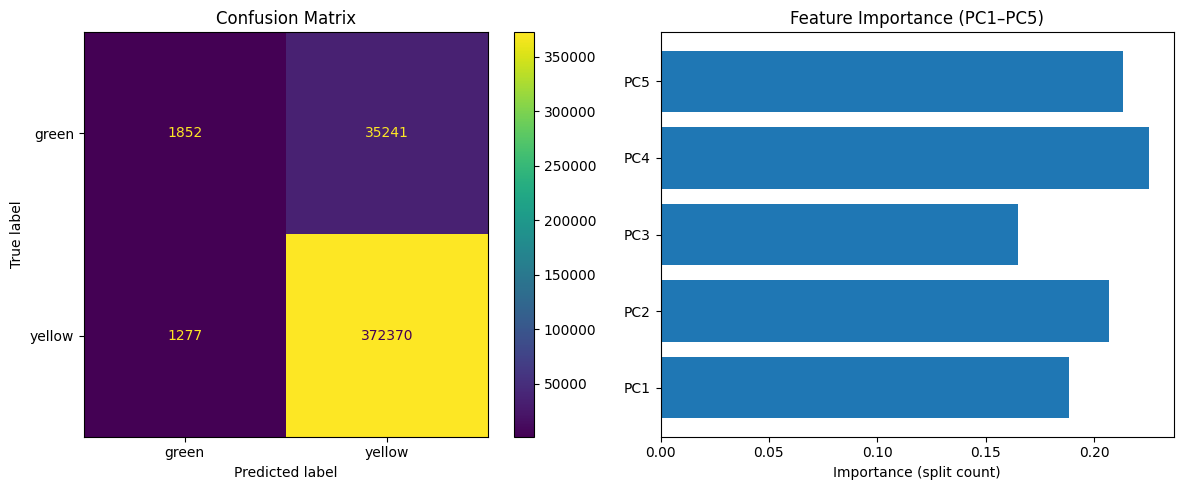

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=classes, ax=axes[0], colorbar=True
)
axes[0].set_title("Confusion Matrix")

# Feature importance (PCs)
importance = clf.feature_importances_
pc_names = [f"PC{i+1}" for i in range(N_PCA_COMPONENTS)]
axes[1].barh(pc_names, importance)
axes[1].set_xlabel("Importance (split count)")
axes[1].set_title("Feature Importance (PC1–PC5)")

plt.tight_layout()
plt.show()

## 6. Extra Credit

This section is **optional** and goes beyond the required Part B model.

We add metadata features from the pivot index and evaluate whether they improve classification:
- From `date`: `year`, `month`, `day_of_week`, `is_weekend`
- From `pickup_place`: parse either `lon_lat` (use `pickup_lon`, `pickup_lat`) or a numeric zone id (`pickup_zone_id`) and include a flag `pickup_is_lonlat`.

We also report bootstrap stability and prediction confidence for the extra-credit model.

[Extra Credit] Using same split as Part B. Classes: ['green' 'yellow']


[Extra Credit] Accuracy: 0.9924

[Extra Credit] Classification Report:
              precision    recall  f1-score   support

       green       0.96      0.96      0.96     37093
      yellow       1.00      1.00      1.00    373647

    accuracy                           0.99    410740
   macro avg       0.98      0.98      0.98    410740
weighted avg       0.99      0.99      0.99    410740



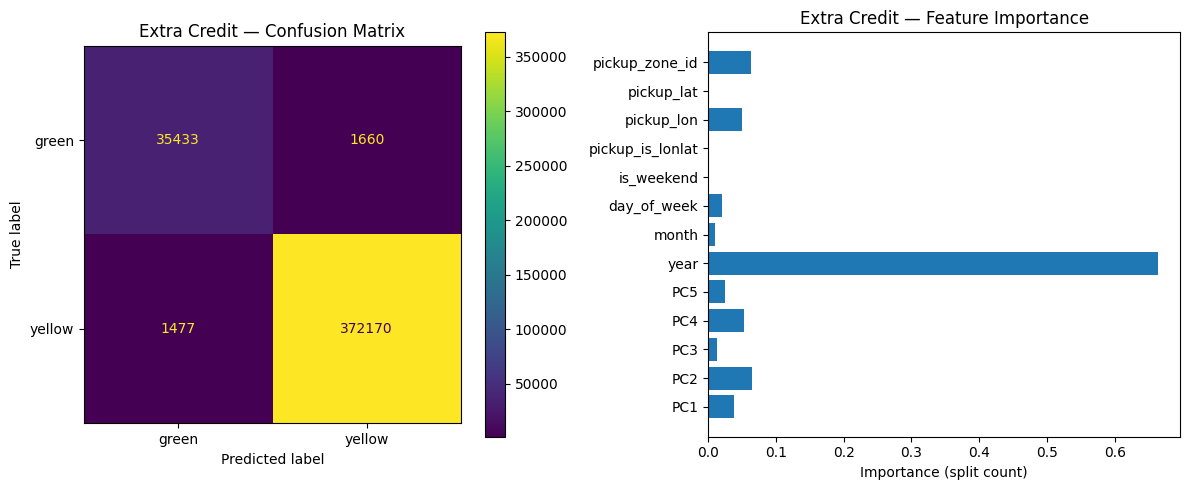

In [19]:
# Extra-credit model: add date + pickup_place metadata features

EXTRA_FEATURE_NAMES_B = [
    "year",
    "month",
    "day_of_week",
    "is_weekend",
    "pickup_is_lonlat",
    "pickup_lon",
    "pickup_lat",
    "pickup_zone_id",
]

meta = pivot_df[["date", "pickup_place"]].copy()
meta["date"] = pd.to_datetime(meta["date"], errors="coerce")
meta["year"] = meta["date"].dt.year
meta["month"] = meta["date"].dt.month
meta["day_of_week"] = meta["date"].dt.dayofweek
meta["is_weekend"] = (meta["day_of_week"] >= 5).astype(int)

pp = meta["pickup_place"].astype(str)
meta["pickup_is_lonlat"] = pp.str.contains("_").astype(int)
_parts = pp.str.split("_", n=1, expand=True)
meta["pickup_lon"] = pd.to_numeric(_parts[0], errors="coerce")
meta["pickup_lat"] = pd.to_numeric(_parts[1], errors="coerce")
meta["pickup_zone_id"] = pd.to_numeric(pp, errors="coerce")

meta["pickup_lon"] = meta["pickup_lon"].fillna(0.0)
meta["pickup_lat"] = meta["pickup_lat"].fillna(0.0)
meta["pickup_zone_id"] = meta["pickup_zone_id"].fillna(-1.0)

X_extra_ec = meta.loc[valid, EXTRA_FEATURE_NAMES_B].to_numpy(dtype=float)
FEATURE_NAMES_EC = [f"PC{i+1}" for i in range(N_PCA_COMPONENTS)] + EXTRA_FEATURE_NAMES_B

# Use the SAME train/test split as Part B (by index), and fit PCA on TRAIN only.
idx_all = np.arange(len(y_raw))
idx_train, idx_test = train_test_split(
    idx_all,
    train_size=TRAIN_FRAC,
    stratify=y,
    random_state=RANDOM_SEED,
)

X_train_raw_ec = X_raw[idx_train]
X_test_raw_ec = X_raw[idx_test]

pca_ec = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
pca_ec.fit(X_train_raw_ec)
X_train_pca_ec = pca_ec.transform(X_train_raw_ec)
X_test_pca_ec = pca_ec.transform(X_test_raw_ec)

X_train_ec = np.concatenate([X_train_pca_ec, X_extra_ec[idx_train]], axis=1)
X_test_ec = np.concatenate([X_test_pca_ec, X_extra_ec[idx_test]], axis=1)

y_train_ec = y[idx_train]
y_test_ec = y[idx_test]
classes_ec = classes
n_class_ec = n_class
print(f"[Extra Credit] Using same split as Part B. Classes: {classes_ec}")

clf_ec = XGBClassifier(
    objective="multi:softprob",
    num_class=n_class_ec,
    random_state=RANDOM_SEED,
    n_jobs=1,
    eval_metric="mlogloss",
)
clf_ec.fit(X_train_ec, y_train_ec)

y_proba_ec = clf_ec.predict_proba(X_test_ec)
if getattr(y_proba_ec, "ndim", 1) == 1:
    y_pred_ec = (y_proba_ec >= 0.5).astype(int)
else:
    y_pred_ec = np.argmax(y_proba_ec, axis=1)

acc_ec = accuracy_score(y_test_ec, y_pred_ec)
print(f"[Extra Credit] Accuracy: {acc_ec:.4f}")
print("\n[Extra Credit] Classification Report:")
print(
    classification_report(
        y_test_ec,
        y_pred_ec,
        labels=np.arange(n_class_ec),
        target_names=classes_ec,
        zero_division=0,
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_ec,
    y_pred_ec,
    display_labels=classes_ec,
    labels=np.arange(n_class_ec),
    ax=axes[0],
    colorbar=True,
)
axes[0].set_title("Extra Credit — Confusion Matrix")

importance_ec = clf_ec.feature_importances_
axes[1].barh(FEATURE_NAMES_EC, importance_ec)
axes[1].set_xlabel("Importance (split count)")
axes[1].set_title("Extra Credit — Feature Importance")

plt.tight_layout()
plt.show()

np.random.seed(RANDOM_SEED)

In [20]:
# Bootstrap stability (extra-credit model): resample test set B times, compute accuracy & F1
n_test = len(y_test_ec)
acc_boot = []
f1_boot = []
for _ in range(N_BOOTSTRAP_B):
    idx = np.random.choice(n_test, size=n_test, replace=True)
    acc_boot.append(accuracy_score(y_test_ec[idx], y_pred_ec[idx]))
    f1_boot.append(
        f1_score(y_test_ec[idx], y_pred_ec[idx], average="weighted", zero_division=0)
    )

acc_boot = np.array(acc_boot)
f1_boot = np.array(f1_boot)
acc_ci = np.percentile(acc_boot, [2.5, 97.5])
f1_ci = np.percentile(f1_boot, [2.5, 97.5])

print("[Extra Credit] Bootstrap stability (test set resampling):")
print(
    f"  Accuracy: {acc_boot.mean():.4f} ± {acc_boot.std():.4f}  95% CI: [{acc_ci[0]:.4f}, {acc_ci[1]:.4f}]"
)
print(
    f"  F1 (weighted): {f1_boot.mean():.4f} ± {f1_boot.std():.4f}  95% CI: [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]"
)

[Extra Credit] Bootstrap stability (test set resampling):
  Accuracy: 0.9923 ± 0.0001  95% CI: [0.9921, 0.9926]
  F1 (weighted): 0.9923 ± 0.0001  95% CI: [0.9921, 0.9926]


In [21]:
# Prediction confidence (extra-credit model): max predicted probability per sample
if getattr(y_proba_ec, "ndim", 1) == 1:
    # Binary case: y_proba_ec = P(class=1)
    confidences = np.maximum(y_proba_ec, 1.0 - y_proba_ec)
else:
    confidences = np.max(y_proba_ec, axis=1)

correct = (y_pred_ec == y_test_ec)
conf_correct = confidences[correct]
conf_incorrect = confidences[~correct]

print("[Extra Credit] Prediction confidence:")
print(f"  Mean confidence (correct):   {conf_correct.mean():.4f} ± {conf_correct.std():.4f}")
print(f"  Mean confidence (incorrect): {conf_incorrect.mean():.4f} ± {conf_incorrect.std():.4f}")

[Extra Credit] Prediction confidence:
  Mean confidence (correct):   0.9876 ± 0.0490
  Mean confidence (incorrect): 0.6868 ± 0.1349


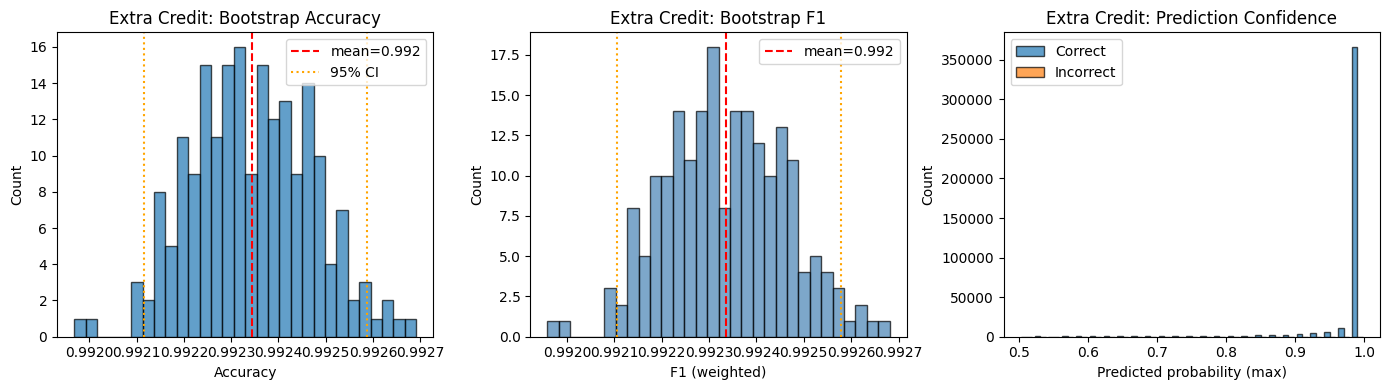

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Bootstrap distribution of accuracy
axes[0].hist(acc_boot, bins=30, edgecolor="black", alpha=0.7)
axes[0].axvline(acc_boot.mean(), color="red", ls="--", label=f"mean={acc_boot.mean():.3f}")
axes[0].axvline(acc_ci[0], color="orange", ls=":", label="95% CI")
axes[0].axvline(acc_ci[1], color="orange", ls=":")
axes[0].set_xlabel("Accuracy")
axes[0].set_ylabel("Count")
axes[0].set_title("Extra Credit: Bootstrap Accuracy")
axes[0].legend()

# Bootstrap distribution of F1
axes[1].hist(f1_boot, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].axvline(f1_boot.mean(), color="red", ls="--", label=f"mean={f1_boot.mean():.3f}")
axes[1].axvline(f1_ci[0], color="orange", ls=":")
axes[1].axvline(f1_ci[1], color="orange", ls=":")
axes[1].set_xlabel("F1 (weighted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Extra Credit: Bootstrap F1")
axes[1].legend()

# Prediction confidence: correct vs incorrect
axes[2].hist([conf_correct, conf_incorrect], bins=25, label=["Correct", "Incorrect"], alpha=0.7, edgecolor="black")
axes[2].set_xlabel("Predicted probability (max)")
axes[2].set_ylabel("Count")
axes[2].set_title("Extra Credit: Prediction Confidence")
axes[2].legend()

plt.tight_layout()
plt.show()